# Libraries

In [1]:
import sys
import os

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

- `os.getcwd()` → gives you the current working directory of the notebook process.
- `os.path.join(os.getcwd(), '..')` → moves one level up in the folder structure.
- `os.path.abspath(...)` → ensures the result is an absolute path, not a relative one.
- `sys.path.append(...)` → adds that folder to Python’s import search path, so now Python will look there when trying to import modules. It's important because Python searches for modules in the directories listed in sys.path.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from simple_linear_regression import utils
from simple_linear_regression.linear_model import SimpleLinearRegression
from sklearn.model_selection import train_test_split

# Defining Parameters

In [4]:
seed = 42
train_size = 0.8
prefix_path = "../"

# Loading Data

In [5]:
data = pd.read_csv(prefix_path + "src/salary_dataset.csv", index_col=0)

In [6]:
data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


# Split Train and Test Data

In [7]:
X, y = np.array(data["YearsExperience"]), np.array(data["Salary"])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=seed)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((24,), (6,), (24,), (6,))

# Saving Data

In [10]:
utils.save_data(use="train", X=X_train, y=y_train)
utils.save_data(use="test", X=X_test, y=y_test)

# Normalizing Data

In [11]:
X_train = utils.normalization(X_train)
y_train = utils.normalization(y_train)
X_test = utils.normalization(X_test)
y_test = utils.normalization(y_test)

# Instance of model

In [12]:
MAX_ITERATIONS = 2e5
TOLERANCE = 1e-2

In [13]:
model = SimpleLinearRegression(lr=0.1, tolerance=TOLERANCE, n_iterations=MAX_ITERATIONS, 
                            metric="mse", method="gd")

In [14]:
model.fit(X=X_train, y=y_train)

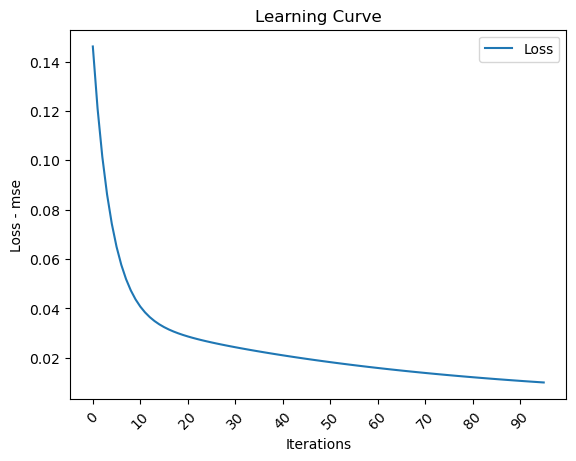

In [15]:
model.learning_curve

In [16]:
model.info

{'tolerance': 0.01,
 'user_limit_iterations': 200000.0,
 'model_real_iterations_executed': 95,
 'learning_rate': 0.1,
 'metric': 'mse',
 'method': 'gd',
 'weights': (np.float64(0.6349573479905842), np.float64(0.1698779031918394)),
 'weights_history': [(np.float64(0.028565598962391078),
   np.float64(0.043086020552799434)),
  (np.float64(0.05444914433974296), np.float64(0.0806212913294809)),
  (np.float64(0.0779679159994931), np.float64(0.113277513839878)),
  (np.float64(0.0994010054612447), np.float64(0.14164542283158402)),
  (np.float64(0.11899391751318371), np.float64(0.16624454354991827)),
  (np.float64(0.13696261730269726), np.float64(0.18753177317501163)),
  (np.float64(0.153497089725607), np.float64(0.20590892813132292)),
  (np.float64(0.16876446988559762), np.float64(0.2217293818895707)),
  (np.float64(0.18291179631301419), np.float64(0.23530390286344094)),
  (np.float64(0.19606843240327573), np.float64(0.24690578879554048)),
  (np.float64(0.20834819605685956), np.float64(0.2567